<a href="https://colab.research.google.com/github/sp-mujuni/1-Year-MachineLearning-Journey/blob/master/clustering_run_3_GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial Data and Computational  Intelligence Lab

## Clustering the lab's air quality dataset

**3. Gaussian Mixture Model**

## 1. Importing libraries

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
import os

## 2. Listing files in dataset



In [44]:
# For Google Colab - mount Google Drive if not already mounted
from google.colab import drive  # type: ignore
drive.mount('/content/drive')
# Update this path to match where your Clustering folder is in Google Drive
dataset_path = '/content/drive/MyDrive/2025/AI/Clustering/clean'
print(f"Using Colab path: {dataset_path}")

print(f"Files in dataset: {os.listdir(dataset_path)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab path: /content/drive/MyDrive/2025/AI/Clustering/clean
Files in dataset: ['fantasto_codetect_db_fixed.csv']


## 3. Loading dataset

In [45]:
df = pd.read_csv(f'{dataset_path}/fantasto_codetect_db_fixed.csv')

## 4. Selecting pollutant columns for clustering

In [46]:
features = ['carbondioxide', 'carbonmonoxide', 'dust']
X = df[features].copy()

## 5. Handling missing and invalid values

In [47]:
# Replace missing values with mean
X = X.fillna(X.mean())



In [48]:
# Optional: handle extreme negative dust values if needed
X['dust'] = X['dust'].clip(lower=0)

## 6. Scaling the data

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 7. Applying PCA

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## 8. Determining number of clusters to use

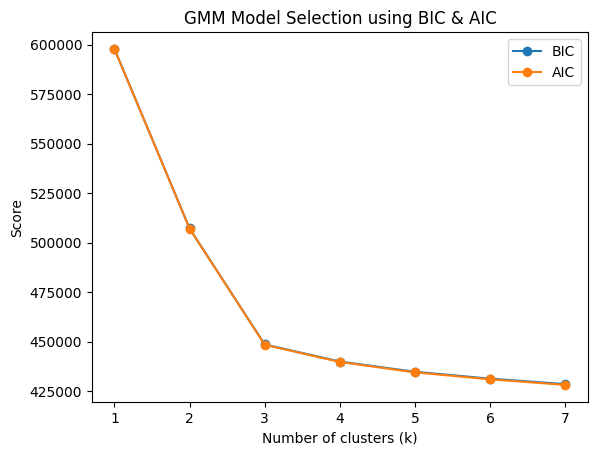

In [51]:
bic = []
aic = []
K = range(1, 8)

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_pca)
    bic.append(gmm.bic(X_pca))
    aic.append(gmm.aic(X_pca))

#Plotting to find k
plt.plot(K, bic, marker='o', label='BIC')
plt.plot(K, aic, marker='o', label='AIC')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Score")
plt.title("GMM Model Selection using BIC & AIC")
plt.legend()
plt.show()

In [52]:
#Validating chosen k
gmm = GaussianMixture(n_components=3, random_state=42)
labels = gmm.fit_predict(X_pca)

df.groupby(labels)[['carbondioxide','carbonmonoxide','dust']].mean()


,carbondioxide,carbonmonoxide,dust
0,649.621480,38.786061,29489.007304
1,673.389051,75.319692,14359.500797
2,643.571797,43.045667,-29490.854718


## 9. Fitting the final GMM Model

In [53]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

labels = gmm.fit_predict(X_pca)


## 10. Assigning Cluster Probabilities

In [54]:
probabilities = gmm.predict_proba(X_pca)


## 11 .Attaching results to the dataset


In [55]:
df['gmm_cluster'] = labels

df['gmm_prob_max'] = probabilities.max(axis=1)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]


##12. Visualizing GMM Clusters

/tmp/ipython-input-1406637929.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


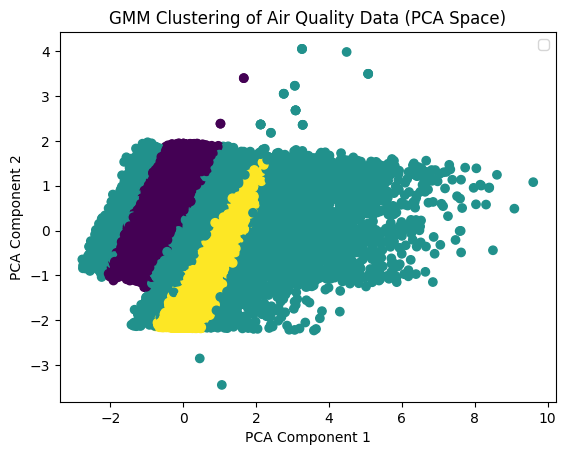

In [56]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("GMM Clustering of Air Quality Data (PCA Space)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


##13. Cluster Probability Analysis

In [57]:
# Fit GMM (already done)

# Posterior probabilities
probs = gmm.predict_proba(X_pca)

# Hard labels (max probability)
labels = probs.argmax(axis=1)


In [58]:
# Defining borderline
max_probs = probs.max(axis=1)
borderline_mask = max_probs < 0.6


In [59]:
# Counting borderline states
borderline_count = borderline_mask.sum()
total_count = len(X_pca)

borderline_count, borderline_count / total_count


(np.int64(1367), np.float64(0.012988617144594568))

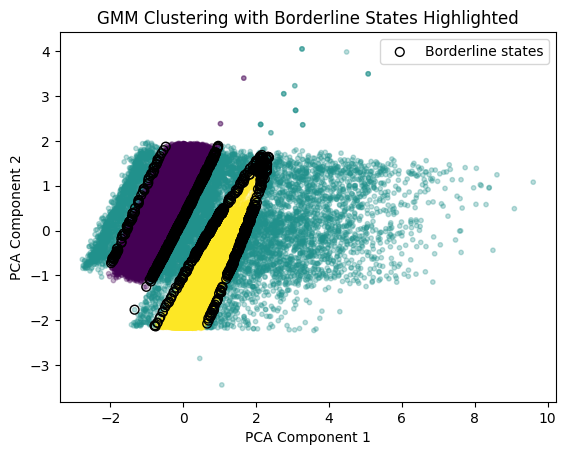

In [60]:
# Visualizing borderline states
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    alpha=0.3,
    s=10
)

plt.scatter(
    X_pca[borderline_mask, 0],
    X_pca[borderline_mask, 1],
    facecolors='none',
    edgecolors='black',
    s=40,
    label='Borderline states'
)

plt.legend()
plt.title("GMM Clustering with Borderline States Highlighted")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [61]:
# Analyzing pollutant values in borderline states

In [62]:
df['borderline'] = borderline_mask

df.groupby('borderline')[['carbondioxide', 'carbonmonoxide', 'dust']].mean()

,carbondioxide,carbonmonoxide,dust
borderline,,,
False,648.394911,42.738754,8211.956074
True,713.880029,52.070958,5107.369422


##14. Time-of-day Analysis of borderline states

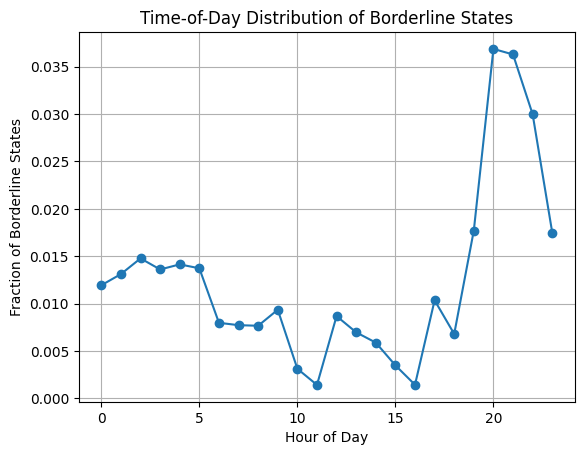

In [63]:
# Adding datetime to dataframe
df['timestamp'] = pd.to_datetime(df['updated_at'])

# Extracting hour
df['hour'] = df['timestamp'].dt.hour

# Computing borderline frequency by hour
hourly_borderline = (
    df.groupby('hour')['borderline']
      .mean()   # fraction of borderline states
)

# Visualizing
plt.plot(hourly_borderline.index, hourly_borderline.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Fraction of Borderline States")
plt.title("Time-of-Day Distribution of Borderline States")
plt.grid(True)
plt.show()


##15. Seasonal/Monthly Analysis of borderline states

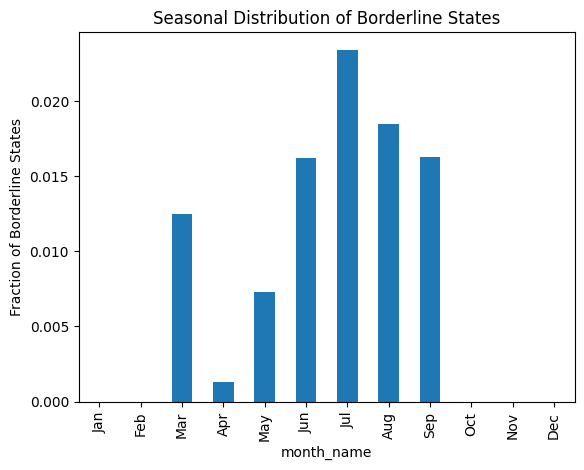

In [64]:
# Extracting month
df['month'] = df['timestamp'].dt.month

# Mapping month names
month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}
df['month_name'] = df['month'].map(month_names)

# Computing monthly borderline frequency
monthly_borderline = (
    df.groupby('month_name')['borderline']
      .mean()
      .reindex(month_names.values())
)

# Plotting
monthly_borderline.plot(kind='bar')
plt.ylabel("Fraction of Borderline States")
plt.title("Seasonal Distribution of Borderline States")
plt.show()
